# Detection of Outliers for Data Cleaning

This notebook accompanies the lecture on outlier detection techniques for data cleaning. It provides practical implementations of the methods discussed in the slides, with examples using both synthetic and real-world datasets.

## Table of Contents

1. [Introduction to Outliers](#introduction)
2. [Statistical Methods](#statistical-methods)
   - [Visualization Techniques](#visualization)
   - [Z-Score Method](#z-score)
   - [IQR Method](#iqr)
   - [Modified Z-Score](#modified-z)
3. [Machine Learning Methods](#ml-methods)
   - [Local Outlier Factor (LOF)](#lof)
   - [Isolation Forest](#isolation-forest)
   - [One-Class SVM](#one-class-svm)
   - [DBSCAN](#dbscan)
4. [Handling Outliers](#handling-outliers)
   - [Removal Strategies](#removal)
   - [Transformation Strategies](#transformation)
   - [Imputation Strategies](#imputation)
   - [Robust Modeling](#robust-modeling)
5. [Method Comparison](#method-comparison)
6. [Case Study](#case-study)
7. [Exercises](#exercises)

## Setup and Required Libraries

In [17]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.svm import OneClassSVM
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.datasets import make_blobs, make_moons

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('colorblind')

# Set random seed for reproducibility
np.random.seed(42)

<a id="introduction"></a>
# 1. Introduction to Outliers

Outliers are data points that differ significantly from other observations. They can be caused by:
- Data entry errors
- Measurement errors
- Experimental errors
- Natural variation (legitimate outliers)

Let's create some synthetic datasets with outliers to explore different detection methods.

In [18]:
# Create a univariate dataset with outliers
normal_data = np.random.normal(loc=50, scale=5, size=100)  # Normal distribution
outliers = np.array([25, 30, 75, 80])  # Outliers
univariate_data = np.concatenate([normal_data, outliers])

# Create a multivariate dataset with outliers
X, _ = make_blobs(n_samples=100, centers=1, n_features=2, random_state=42)
# Add some outliers
outliers_multi = np.array([[7, 7], [-5, -5], [7, -5], [-5, 7]])
multivariate_data = np.vstack([X, outliers_multi])

# Create a more complex dataset with multiple clusters
X_complex, _ = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=1.0, random_state=42)
# Add some outliers
outliers_complex = np.array([[8, 8], [-8, -8], [8, -8], [-8, 8], [0, 10], [10, 0], [-10, 0], [0, -10]])
complex_data = np.vstack([X_complex, outliers_complex])

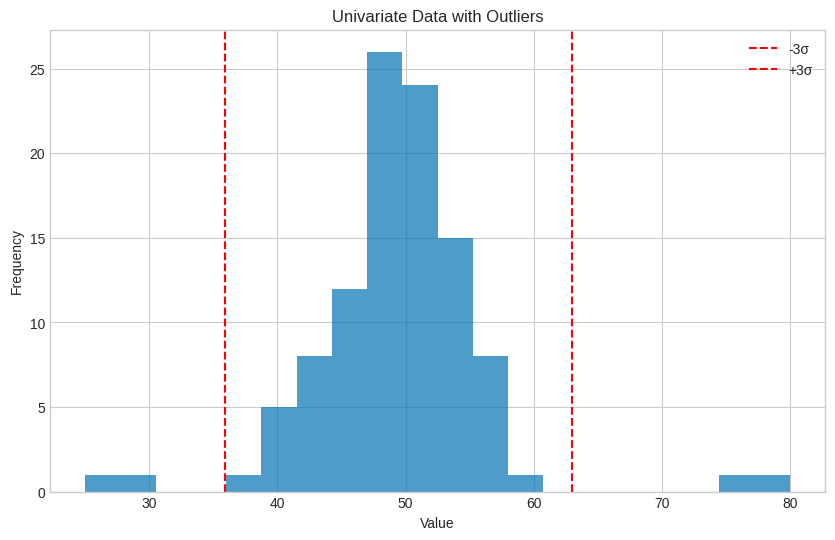

In [19]:
# Visualize the univariate data
plt.figure(figsize=(10, 6))
plt.hist(univariate_data, bins=20, alpha=0.7)
plt.axvline(x=normal_data.mean() - 3*normal_data.std(), color='r', linestyle='--', label='-3σ')
plt.axvline(x=normal_data.mean() + 3*normal_data.std(), color='r', linestyle='--', label='+3σ')
plt.title('Univariate Data with Outliers')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.show()

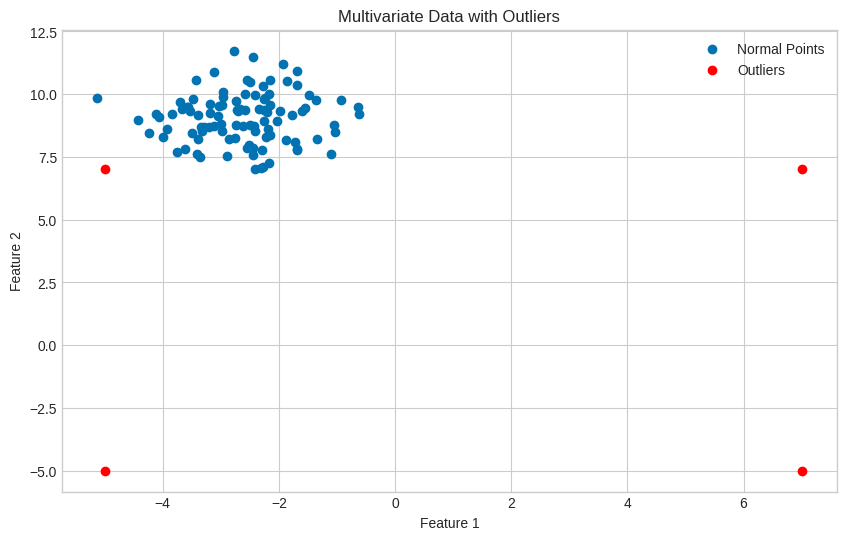

In [20]:
# Visualize the multivariate data
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:-4, 0], multivariate_data[:-4, 1], label='Normal Points')
plt.scatter(multivariate_data[-4:, 0], multivariate_data[-4:, 1], color='red', label='Outliers')
plt.title('Multivariate Data with Outliers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

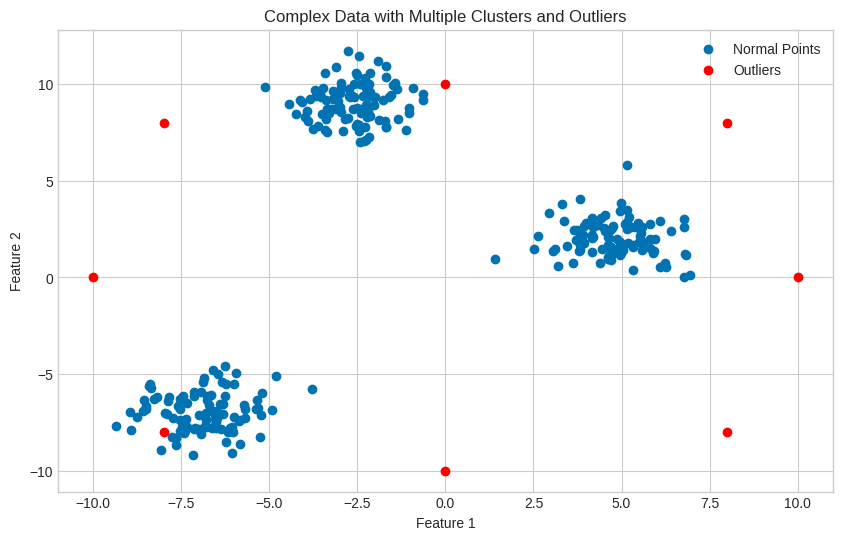

In [21]:
# Visualize the complex data
plt.figure(figsize=(10, 6))
plt.scatter(complex_data[:-8, 0], complex_data[:-8, 1], label='Normal Points')
plt.scatter(complex_data[-8:, 0], complex_data[-8:, 1], color='red', label='Outliers')
plt.title('Complex Data with Multiple Clusters and Outliers')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.show()

<a id="statistical-methods"></a>
# 2. Statistical Methods for Outlier Detection

Statistical methods rely on the distribution properties of data to identify values that deviate significantly from the expected pattern.

<a id="visualization"></a>
## 2.1 Visualization Techniques

Visualization is often the first step in outlier detection. Common techniques include box plots, histograms, and scatter plots.

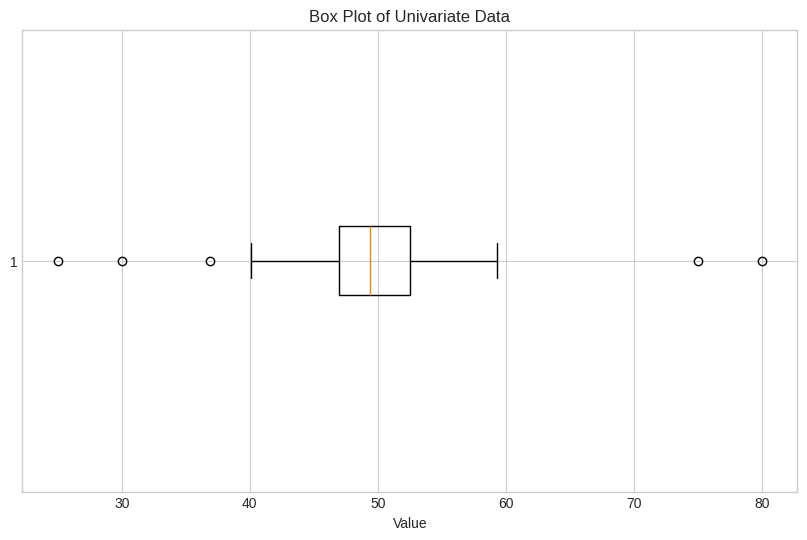

In [22]:
# Box plot for univariate data
plt.figure(figsize=(10, 6))
plt.boxplot(univariate_data, vert=False)
plt.title('Box Plot of Univariate Data')
plt.xlabel('Value')
plt.show()

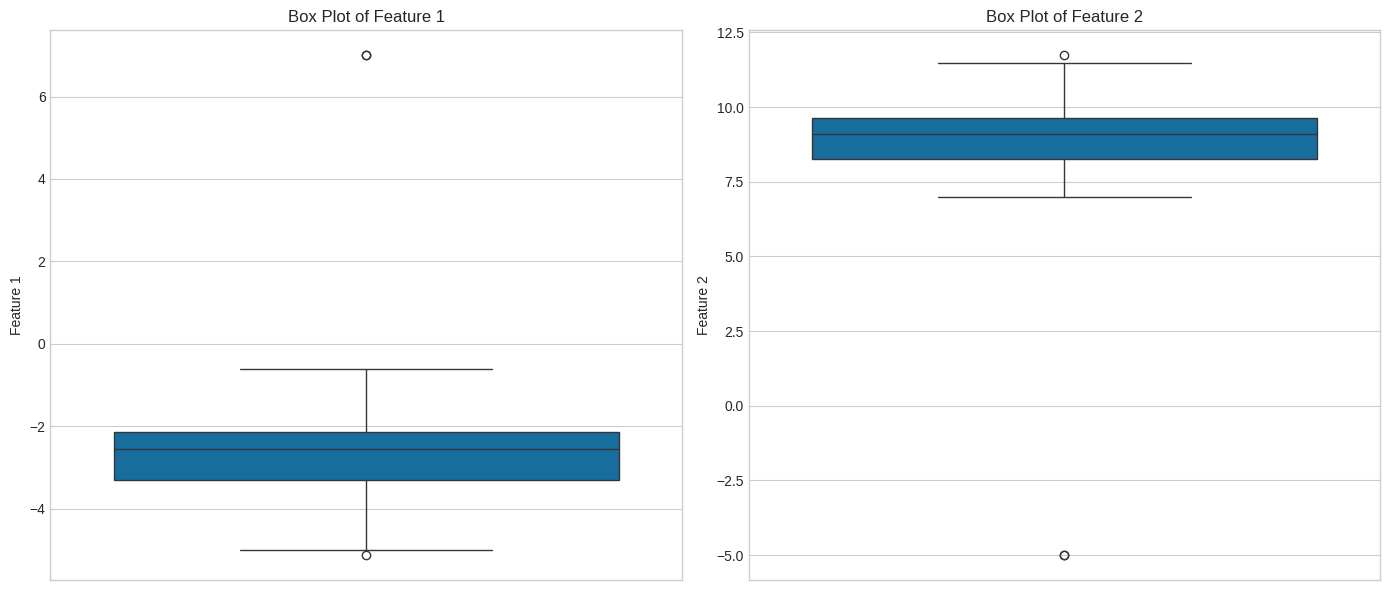

In [23]:
# Create a DataFrame for the multivariate data
df_multi = pd.DataFrame(multivariate_data, columns=['Feature 1', 'Feature 2'])

# Box plots for each feature
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.boxplot(y=df_multi['Feature 1'], ax=axes[0])
axes[0].set_title('Box Plot of Feature 1')
sns.boxplot(y=df_multi['Feature 2'], ax=axes[1])
axes[1].set_title('Box Plot of Feature 2')
plt.tight_layout()
plt.show()

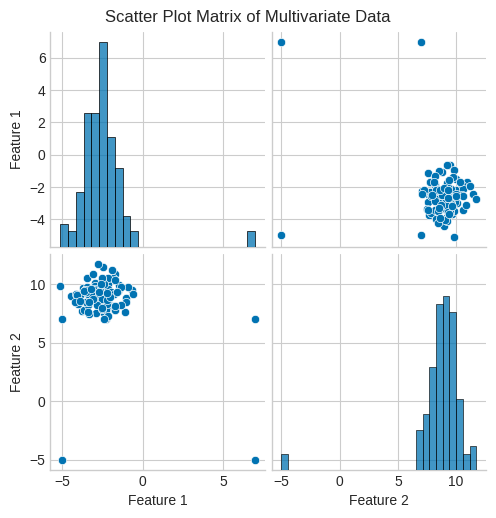

In [24]:
# Scatter plot matrix for multivariate data
sns.pairplot(df_multi)
plt.suptitle('Scatter Plot Matrix of Multivariate Data', y=1.02)
plt.show()

<a id="z-score"></a>
## 2.2 Z-Score Method

The Z-score measures how many standard deviations a data point is from the mean. Points with |Z| > 3 are typically considered outliers.

In [25]:
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using the Z-score method.

    Parameters:
    data (array-like): Input data
    threshold (float): Z-score threshold for outlier detection

    Returns:
    array: Boolean mask where True indicates an outlier
    """
    z_scores = np.abs(stats.zscore(data))
    return z_scores > threshold

Number of outliers detected using Z-score: 3


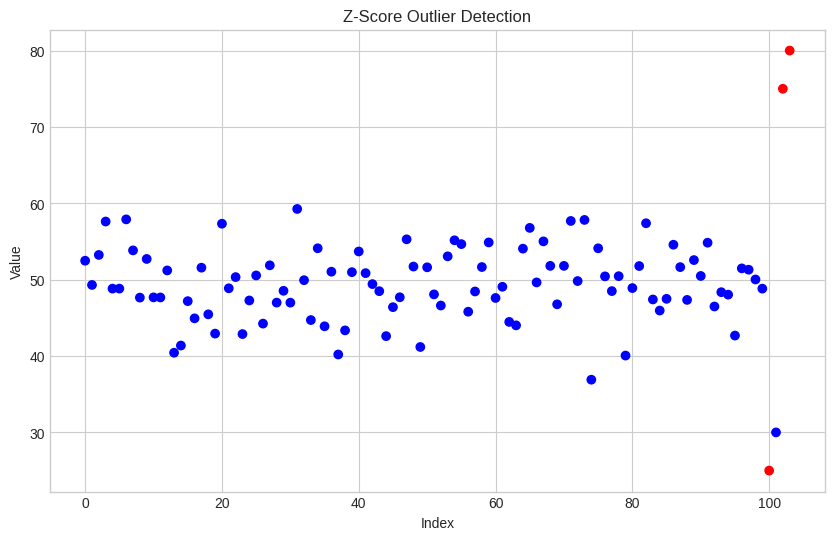

In [26]:
# Apply Z-score method to univariate data
outliers_zscore = detect_outliers_zscore(univariate_data)
print(f"Number of outliers detected using Z-score: {np.sum(outliers_zscore)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(range(len(univariate_data)), univariate_data, c=['red' if x else 'blue' for x in outliers_zscore])
plt.title('Z-Score Outlier Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Number of outliers detected using Z-score: 3


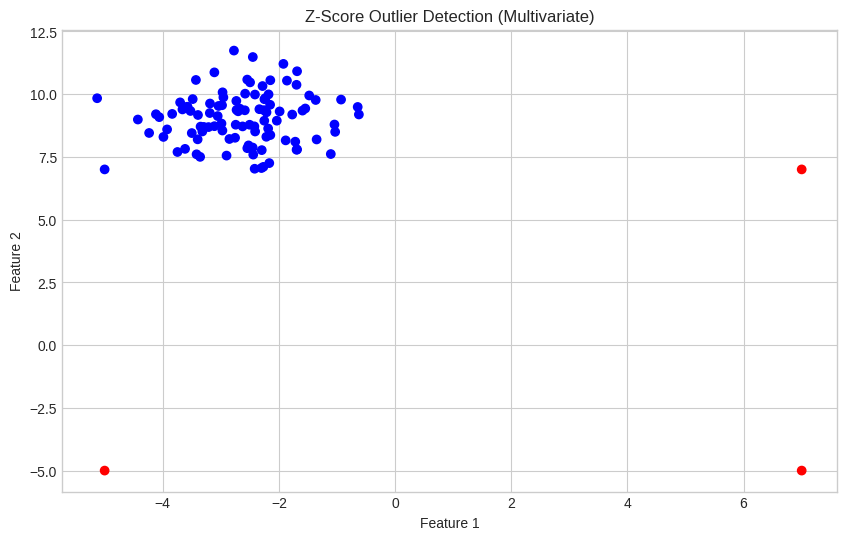

In [27]:
# Apply Z-score method to multivariate data (feature by feature)
outliers_zscore_multi = np.zeros(len(multivariate_data), dtype=bool)
for i in range(multivariate_data.shape[1]):
    outliers_zscore_multi = outliers_zscore_multi | detect_outliers_zscore(multivariate_data[:, i])

print(f"Number of outliers detected using Z-score: {np.sum(outliers_zscore_multi)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:, 0], multivariate_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_zscore_multi])
plt.title('Z-Score Outlier Detection (Multivariate)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<a id="iqr"></a>
## 2.3 IQR Method

The Interquartile Range (IQR) method uses quartiles to identify outliers without assuming a specific distribution. Points outside Q1 - 1.5×IQR and Q3 + 1.5×IQR are considered outliers.

In [28]:
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using the IQR method.

    Parameters:
    data (array-like): Input data
    factor (float): Multiplier for IQR (default: 1.5)

    Returns:
    array: Boolean mask where True indicates an outlier
    """
    q1 = np.percentile(data, 25)
    q3 = np.percentile(data, 75)
    iqr = q3 - q1
    lower_bound = q1 - factor * iqr
    upper_bound = q3 + factor * iqr
    return (data < lower_bound) | (data > upper_bound)

Number of outliers detected using IQR: 5


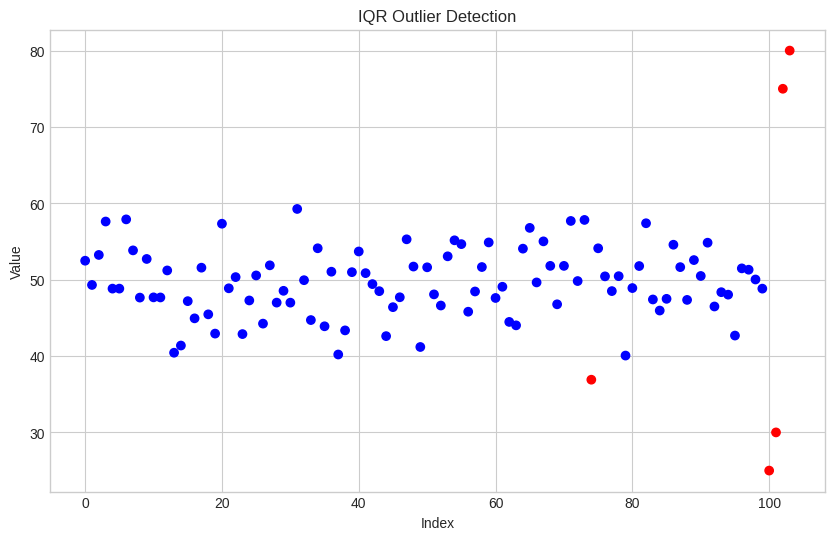

In [29]:
# Apply IQR method to univariate data
outliers_iqr = detect_outliers_iqr(univariate_data)
print(f"Number of outliers detected using IQR: {np.sum(outliers_iqr)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(range(len(univariate_data)), univariate_data, c=['red' if x else 'blue' for x in outliers_iqr])
plt.title('IQR Outlier Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Number of outliers detected using IQR: 5


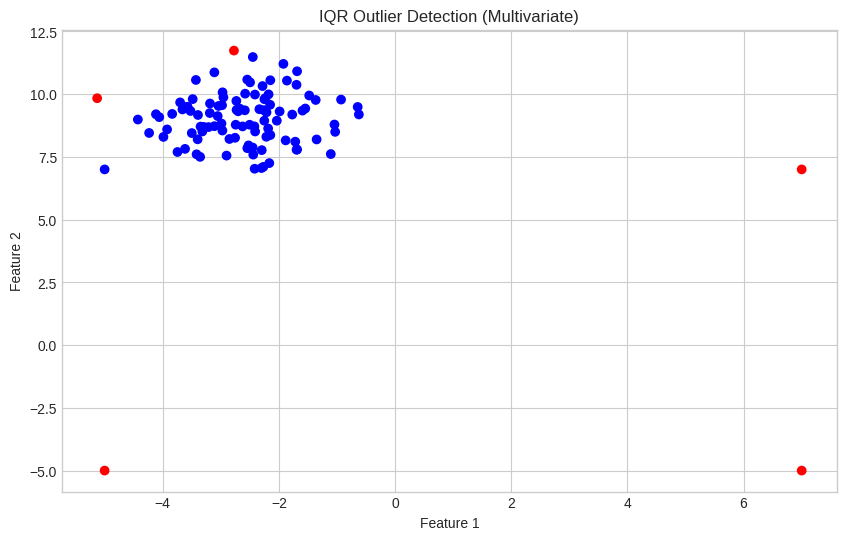

In [30]:
# Apply IQR method to multivariate data (feature by feature)
outliers_iqr_multi = np.zeros(len(multivariate_data), dtype=bool)
for i in range(multivariate_data.shape[1]):
    outliers_iqr_multi = outliers_iqr_multi | detect_outliers_iqr(multivariate_data[:, i])

print(f"Number of outliers detected using IQR: {np.sum(outliers_iqr_multi)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:, 0], multivariate_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_iqr_multi])
plt.title('IQR Outlier Detection (Multivariate)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<a id="modified-z"></a>
## 2.4 Modified Z-Score

The Modified Z-score uses median and Median Absolute Deviation (MAD) instead of mean and standard deviation, making it more robust to outliers.

In [31]:
def detect_outliers_modified_zscore(data, threshold=3.5):
    """
    Detect outliers using the Modified Z-score method.

    Parameters:
    data (array-like): Input data
    threshold (float): Modified Z-score threshold for outlier detection

    Returns:
    array: Boolean mask where True indicates an outlier
    """
    median = np.median(data)
    mad = np.median(np.abs(data - median))
    # Avoid division by zero
    if mad == 0:
        return np.zeros(len(data), dtype=bool)
    modified_z_scores = 0.6745 * np.abs(data - median) / mad
    return modified_z_scores > threshold

Number of outliers detected using Modified Z-score: 4


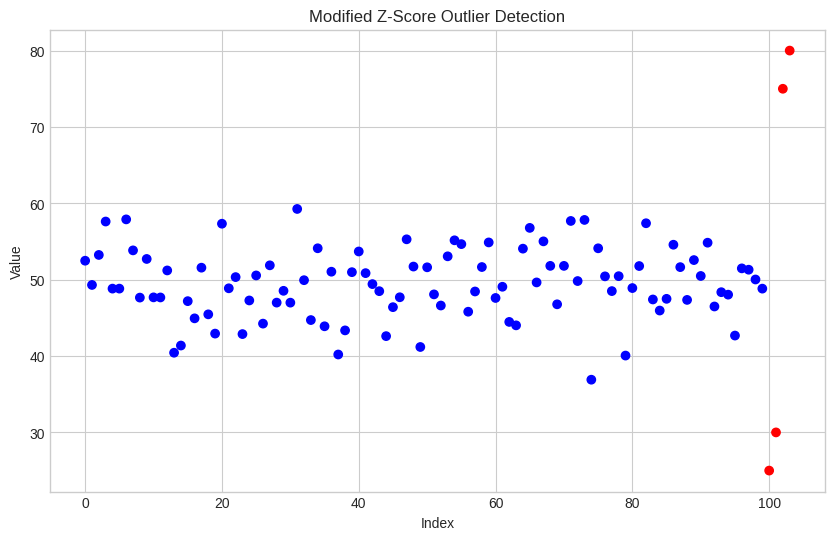

In [32]:
# Apply Modified Z-score method to univariate data
outliers_mod_z = detect_outliers_modified_zscore(univariate_data)
print(f"Number of outliers detected using Modified Z-score: {np.sum(outliers_mod_z)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(range(len(univariate_data)), univariate_data, c=['red' if x else 'blue' for x in outliers_mod_z])
plt.title('Modified Z-Score Outlier Detection')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Number of outliers detected using Modified Z-score: 3


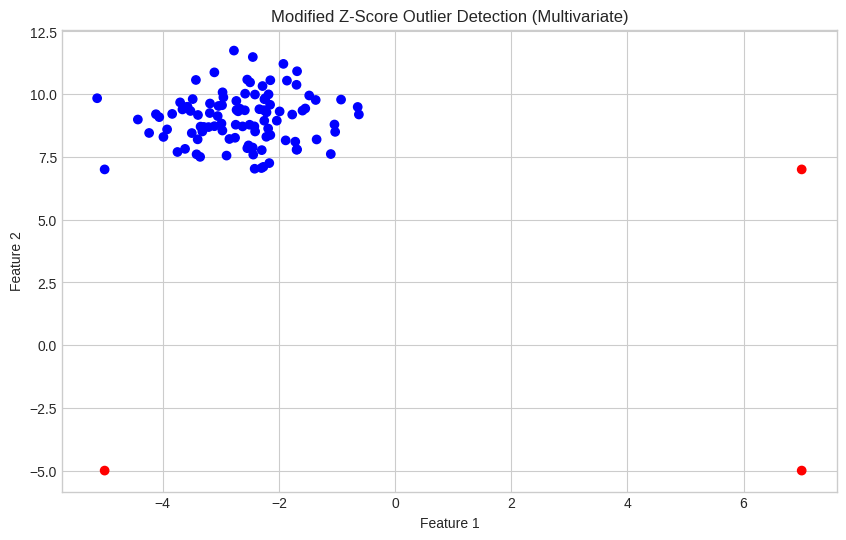

In [33]:
# Apply Modified Z-score method to multivariate data (feature by feature)
outliers_mod_z_multi = np.zeros(len(multivariate_data), dtype=bool)
for i in range(multivariate_data.shape[1]):
    outliers_mod_z_multi = outliers_mod_z_multi | detect_outliers_modified_zscore(multivariate_data[:, i])

print(f"Number of outliers detected using Modified Z-score: {np.sum(outliers_mod_z_multi)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:, 0], multivariate_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_mod_z_multi])
plt.title('Modified Z-Score Outlier Detection (Multivariate)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<a id="ml-methods"></a>
# 3. Machine Learning Methods for Outlier Detection

Machine learning methods can detect complex patterns and are particularly useful for high-dimensional data.

<a id="lof"></a>
## 3.1 Local Outlier Factor (LOF)

LOF compares the local density of a point with the local densities of its neighbors. Points with significantly lower density than their neighbors are considered outliers.

In [36]:
def detect_outliers_lof(data, n_neighbors=20, contamination=0.1):
    """
    Detect outliers using Local Outlier Factor.

    Parameters:
    data (array-like): Input data
    n_neighbors (int): Number of neighbors to consider
    contamination (float): Expected proportion of outliers

    Returns:
    tuple: (outlier_mask, lof_scores)
    """
    # Reshape 1D data for sklearn
    if len(data.shape) == 1:
        data = data.reshape(-1, 1)

    # Apply LOF
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    y_pred = lof.fit_predict(data)
    outlier_mask = y_pred == -1

    # Get negative outlier factor (higher means more likely to be an outlier)
    lof_scores = -lof.negative_outlier_factor_

    return outlier_mask, lof_scores

Number of outliers detected using LOF: 6


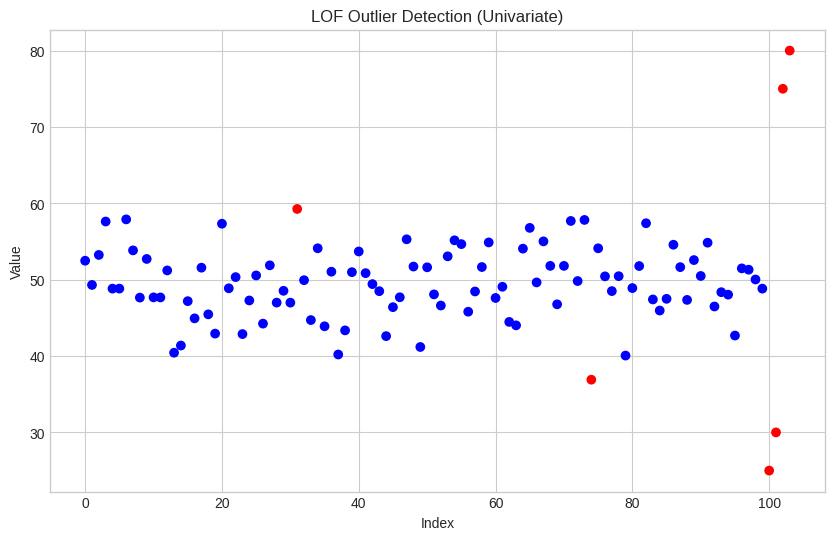

In [37]:
# Apply LOF to univariate data
outliers_lof_uni, lof_scores_uni = detect_outliers_lof(univariate_data, contamination=0.05)
print(f"Number of outliers detected using LOF: {np.sum(outliers_lof_uni)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(range(len(univariate_data)), univariate_data, c=['red' if x else 'blue' for x in outliers_lof_uni])
plt.title('LOF Outlier Detection (Univariate)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Number of outliers detected using LOF: 6


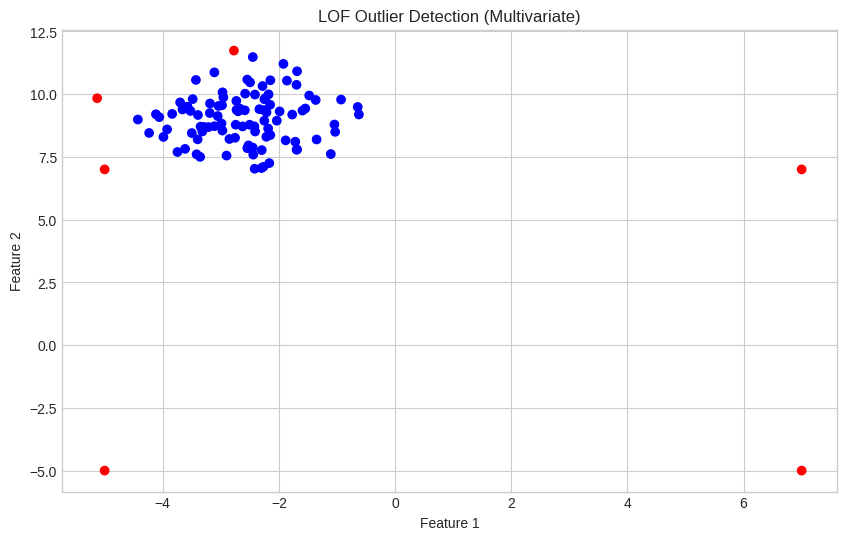

In [38]:
# Apply LOF to multivariate data
outliers_lof_multi, lof_scores_multi = detect_outliers_lof(multivariate_data, contamination=0.05)
print(f"Number of outliers detected using LOF: {np.sum(outliers_lof_multi)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:, 0], multivariate_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_lof_multi])
plt.title('LOF Outlier Detection (Multivariate)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Number of outliers detected using LOF: 10


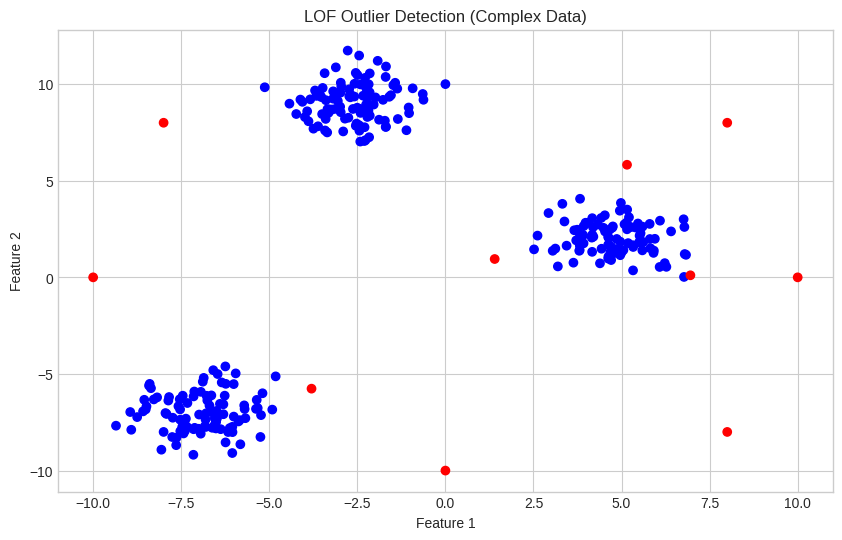

In [39]:
# Apply LOF to complex data
outliers_lof_complex, lof_scores_complex = detect_outliers_lof(complex_data, contamination=0.03)
print(f"Number of outliers detected using LOF: {np.sum(outliers_lof_complex)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(complex_data[:, 0], complex_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_lof_complex])
plt.title('LOF Outlier Detection (Complex Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<a id="isolation-forest"></a>
## 3.2 Isolation Forest

Isolation Forest is based on the principle that outliers are easier to isolate than normal points. It uses random partitioning to create isolation trees.

In [40]:
def detect_outliers_iforest(data, n_estimators=100, contamination=0.1):
    """
    Detect outliers using Isolation Forest.

    Parameters:
    data (array-like): Input data
    n_estimators (int): Number of trees
    contamination (float): Expected proportion of outliers

    Returns:
    tuple: (outlier_mask, anomaly_scores)
    """
    # Reshape 1D data for sklearn
    if len(data.shape) == 1:
        data = data.reshape(-1, 1)

    # Apply Isolation Forest
    iforest = IsolationForest(n_estimators=n_estimators, contamination=contamination, random_state=42)
    y_pred = iforest.fit_predict(data)
    outlier_mask = y_pred == -1

    # Get anomaly scores
    anomaly_scores = -iforest.decision_function(data)  # Higher means more likely to be an outlier

    return outlier_mask, anomaly_scores

Number of outliers detected using Isolation Forest: 6


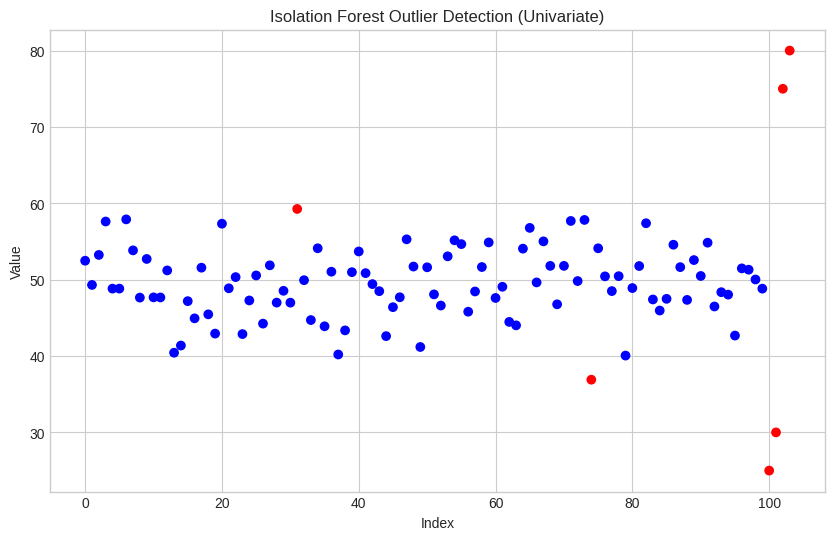

In [41]:
# Apply Isolation Forest to univariate data
outliers_if_uni, if_scores_uni = detect_outliers_iforest(univariate_data, contamination=0.05)
print(f"Number of outliers detected using Isolation Forest: {np.sum(outliers_if_uni)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(range(len(univariate_data)), univariate_data, c=['red' if x else 'blue' for x in outliers_if_uni])
plt.title('Isolation Forest Outlier Detection (Univariate)')
plt.xlabel('Index')
plt.ylabel('Value')
plt.show()

Number of outliers detected using Isolation Forest: 6


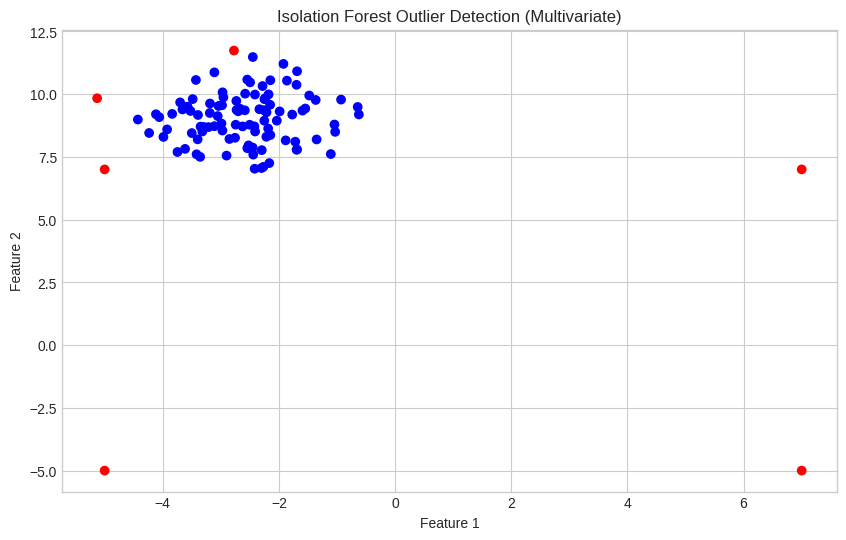

In [42]:
# Apply Isolation Forest to multivariate data
outliers_if_multi, if_scores_multi = detect_outliers_iforest(multivariate_data, contamination=0.05)
print(f"Number of outliers detected using Isolation Forest: {np.sum(outliers_if_multi)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:, 0], multivariate_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_if_multi])
plt.title('Isolation Forest Outlier Detection (Multivariate)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Number of outliers detected using Isolation Forest: 10


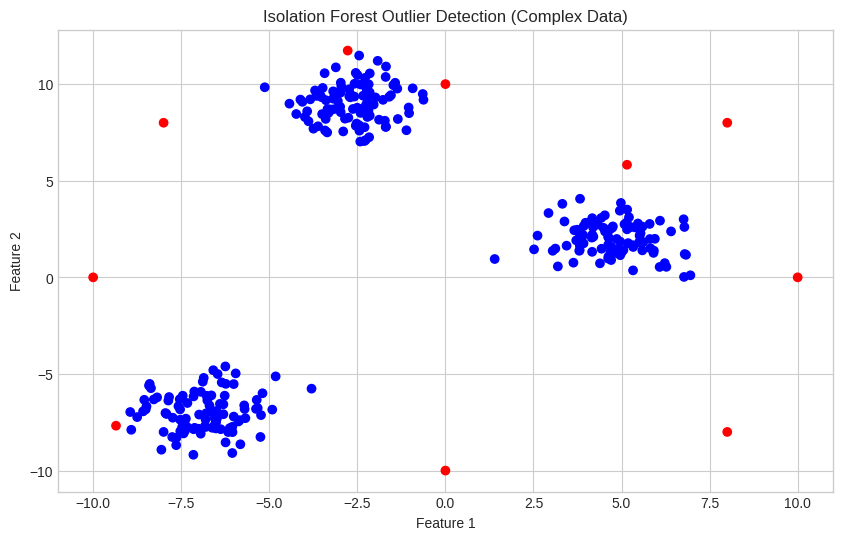

In [43]:
# Apply Isolation Forest to complex data
outliers_if_complex, if_scores_complex = detect_outliers_iforest(complex_data, contamination=0.03)
print(f"Number of outliers detected using Isolation Forest: {np.sum(outliers_if_complex)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(complex_data[:, 0], complex_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_if_complex])
plt.title('Isolation Forest Outlier Detection (Complex Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<a id="one-class-svm"></a>
## 3.3 One-Class SVM

One-Class SVM learns a decision boundary that separates normal data from outliers.

In [44]:
def detect_outliers_ocsvm(data, nu=0.05, kernel='rbf'):
    """
    Detect outliers using One-Class SVM.

    Parameters:
    data (array-like): Input data
    nu (float): Upper bound on the fraction of training errors
    kernel (str): Kernel type

    Returns:
    tuple: (outlier_mask, decision_scores)
    """
    # Reshape 1D data for sklearn
    if len(data.shape) == 1:
        data = data.reshape(-1, 1)

    # Scale the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Apply One-Class SVM
    ocsvm = OneClassSVM(nu=nu, kernel=kernel)
    y_pred = ocsvm.fit_predict(data_scaled)
    outlier_mask = y_pred == -1

    # Get decision scores
    decision_scores = -ocsvm.decision_function(data_scaled)  # Higher means more likely to be an outlier

    return outlier_mask, decision_scores

In [27]:
def plot_ocsvm_boundary(data, outlier_mask, nu=0.05, title='One-Class SVM Decision Boundary',
                        planted=None, zoom=None):
    """
    Draw the One-Class SVM decision boundary over 2D data.

    Parameters:
    data (array-like): 2D input data
    outlier_mask (array-like): Boolean mask from detect_outliers_ocsvm
    nu (float): Same nu used for detection
    title (str): Plot title
    planted (array-like): Known outliers to mark with a cross (optional)
    zoom (tuple): (x, y, half_width) of a region to enlarge in an inset (optional)
    """
    # Refit on the same scaled data; the fit is deterministic, so it matches detect_outliers_ocsvm
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)
    ocsvm = OneClassSVM(nu=nu, kernel='rbf').fit(data_scaled)

    def draw(ax, x_range, y_range, n=300):
        # Inside the boundary (score >= 0) is normal; outside is flagged as an outlier
        xx, yy = np.meshgrid(np.linspace(*x_range, n), np.linspace(*y_range, n))
        Z = ocsvm.decision_function(scaler.transform(np.c_[xx.ravel(), yy.ravel()])).reshape(xx.shape)
        ax.contourf(xx, yy, Z, levels=[min(Z.min(), -1e-9), 0], colors='mistyrose')
        if Z.max() > 0:
            ax.contourf(xx, yy, Z, levels=[0, Z.max()], colors='aliceblue')
            ax.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
        ax.scatter(data[~outlier_mask, 0], data[~outlier_mask, 1], c='blue', s=20, label='Normal')
        ax.scatter(data[outlier_mask, 0], data[outlier_mask, 1], c='red', s=40, label='Outlier')
        if planted is not None:
            ax.scatter(planted[:, 0], planted[:, 1], marker='x', c='black', s=150, linewidths=2,
                       label='Planted outlier')
        ax.set_xlim(x_range); ax.set_ylim(y_range)

    fig, ax = plt.subplots(figsize=(10, 6))
    pad = 0.1 * (data.max(axis=0) - data.min(axis=0))
    draw(ax, (data[:, 0].min() - pad[0], data[:, 0].max() + pad[0]),
             (data[:, 1].min() - pad[1], data[:, 1].max() + pad[1]))
    ax.plot([], [], color='black', linewidth=2, label='Decision boundary (score = 0)')

    if zoom is not None:
        # Enlarge a small region so a boundary too small to see at full scale shows up
        x0, y0, h = zoom
        inset = ax.inset_axes([0.42, 0.08, 0.3, 0.42])
        draw(inset, (x0 - h, x0 + h), (y0 - h, y0 + h), n=400)
        inset.set_xticks([]); inset.set_yticks([])
        inset.set_title(f'zoom around ({x0}, {y0})', fontsize=9)
        ax.indicate_inset_zoom(inset, edgecolor='black')

    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    ax.legend(loc='upper right')
    plt.show()

The black line is where the One-Class SVM decision function equals 0. Points inside it are treated as normal; points outside are flagged as outliers. `nu` is an upper bound on the fraction of training points left outside the boundary.

Number of outliers detected using One-Class SVM: 4


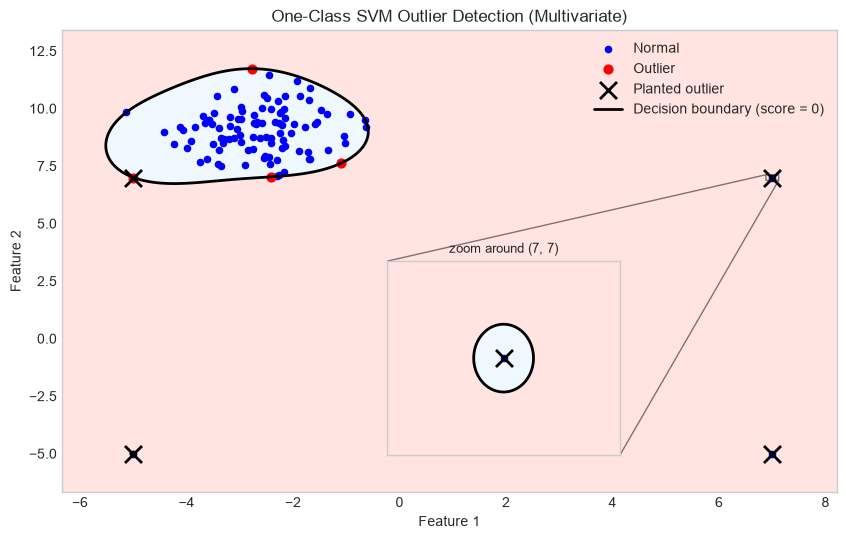

In [28]:
# Apply One-Class SVM to multivariate data
outliers_ocsvm_multi, ocsvm_scores_multi = detect_outliers_ocsvm(multivariate_data, nu=0.05)
print(f"Number of outliers detected using One-Class SVM: {np.sum(outliers_ocsvm_multi)}")

# Visualize the results with the decision boundary
plot_ocsvm_boundary(multivariate_data, outliers_ocsvm_multi, nu=0.05,
                    title='One-Class SVM Outlier Detection (Multivariate)',
                    planted=outliers_multi, zoom=(7, 7, 0.12))

The crosses mark the four outliers we planted. Only (-5, 7) turns red. The other three, (7, 7), (-5, -5) and (7, -5), are called normal even though they sit far outside the black boundary around the blob.

The zoomed panel shows why. One-Class SVM builds its normal region from small bumps around some training points, the support vectors. A far point cannot be covered by the blob's region, so the model gives it a bump of its own: a tiny island of "normal" around that one point. At (7, 7) the score is just above 0, and 0.05 units away it is already negative.

`nu=0.05` caps how many points may be left outside, about 5 of 104. It does not choose which ones. Here the model leaves out 4 points on the edge of the blob and keeps three far points as islands. With these settings, One-Class SVM covers isolated outliers instead of rejecting them.

Number of outliers detected using One-Class SVM: 7


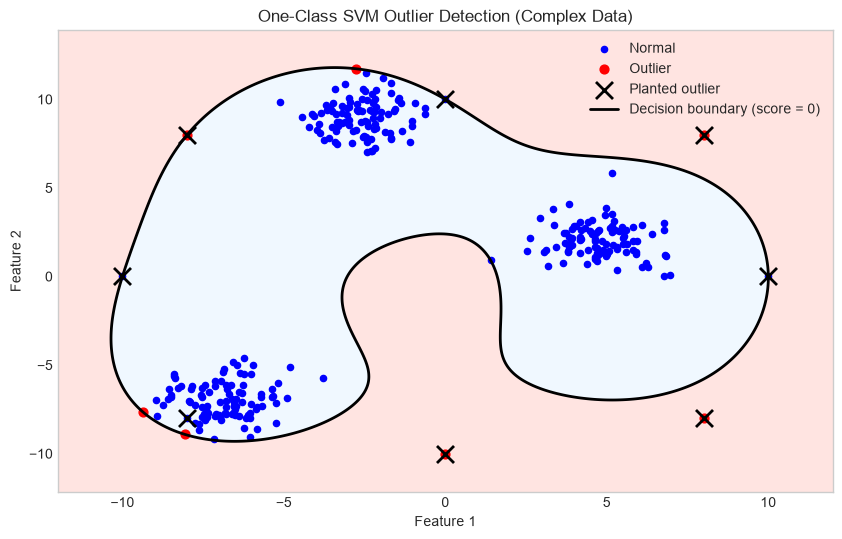

In [29]:
# Apply One-Class SVM to complex data
outliers_ocsvm_complex, ocsvm_scores_complex = detect_outliers_ocsvm(complex_data, nu=0.03)
print(f"Number of outliers detected using One-Class SVM: {np.sum(outliers_ocsvm_complex)}")

# Visualize the results with the decision boundary
plot_ocsvm_boundary(complex_data, outliers_ocsvm_complex, nu=0.03,
                    title='One-Class SVM Outlier Detection (Complex Data)',
                    planted=outliers_complex)

On the three clusters, 4 of the 8 planted outliers (crosses) are flagged. (0, 10), (10, 0) and (-10, 0) sit on the boundary itself, and (-8, -8) falls inside it beside the lower-left cluster. The other 3 flagged points are cluster members at the edge of the region.

<a id="dbscan"></a>
## 3.4 DBSCAN

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) identifies clusters as dense regions separated by regions of lower density. Points that are not part of any cluster are considered outliers.

In [47]:
def detect_outliers_dbscan(data, eps=0.5, min_samples=5):
    """
    Detect outliers using DBSCAN.

    Parameters:
    data (array-like): Input data
    eps (float): Maximum distance between two samples for them to be considered as in the same neighborhood
    min_samples (int): Number of samples in a neighborhood for a point to be considered as a core point

    Returns:
    array: Boolean mask where True indicates an outlier
    """
    # Reshape 1D data for sklearn
    if len(data.shape) == 1:
        data = data.reshape(-1, 1)

    # Scale the data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    # Apply DBSCAN
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(data_scaled)

    # Points with label -1 are outliers
    outlier_mask = labels == -1

    return outlier_mask

Number of outliers detected using DBSCAN: 5


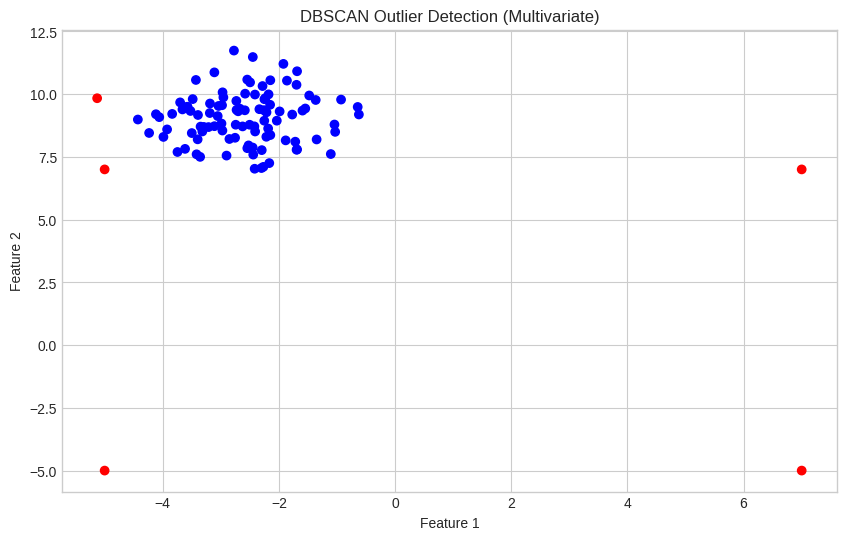

In [48]:
# Apply DBSCAN to multivariate data
outliers_dbscan_multi = detect_outliers_dbscan(multivariate_data, eps=0.5, min_samples=5)
print(f"Number of outliers detected using DBSCAN: {np.sum(outliers_dbscan_multi)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(multivariate_data[:, 0], multivariate_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_dbscan_multi])
plt.title('DBSCAN Outlier Detection (Multivariate)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

Number of outliers detected using DBSCAN: 6


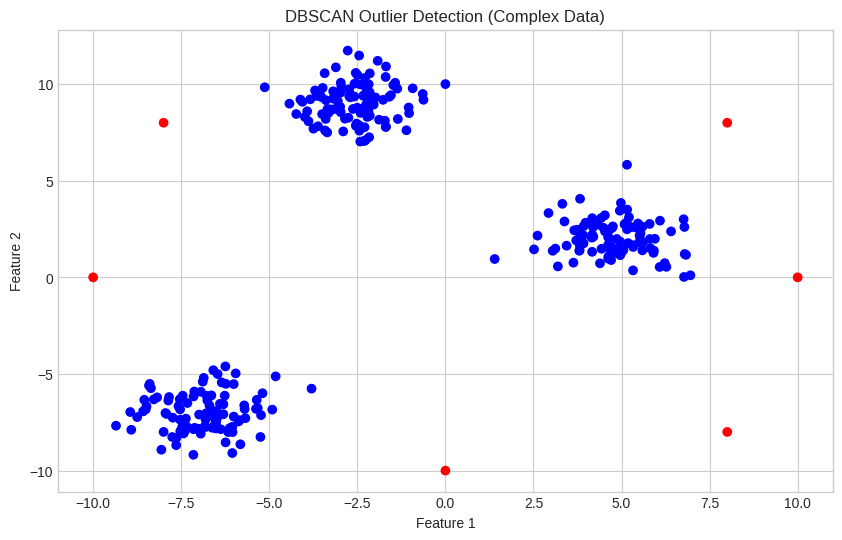

In [49]:
# Apply DBSCAN to complex data
outliers_dbscan_complex = detect_outliers_dbscan(complex_data, eps=0.5, min_samples=5)
print(f"Number of outliers detected using DBSCAN: {np.sum(outliers_dbscan_complex)}")

# Visualize the results
plt.figure(figsize=(10, 6))
plt.scatter(complex_data[:, 0], complex_data[:, 1],
            c=['red' if x else 'blue' for x in outliers_dbscan_complex])
plt.title('DBSCAN Outlier Detection (Complex Data)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

<a id="handling-outliers"></a>
# 4. Handling Outliers

Once outliers are detected, there are several strategies for handling them.

<a id="removal"></a>
## 4.1 Removal Strategies

Removing outliers is the simplest approach but may lead to loss of information.

With outliers:
Mean: 49.60
Std: 6.65
Min: 25.00
Max: 80.00

Without outliers:
Mean: 49.29
Std: 4.89
Min: 30.00
Max: 59.26


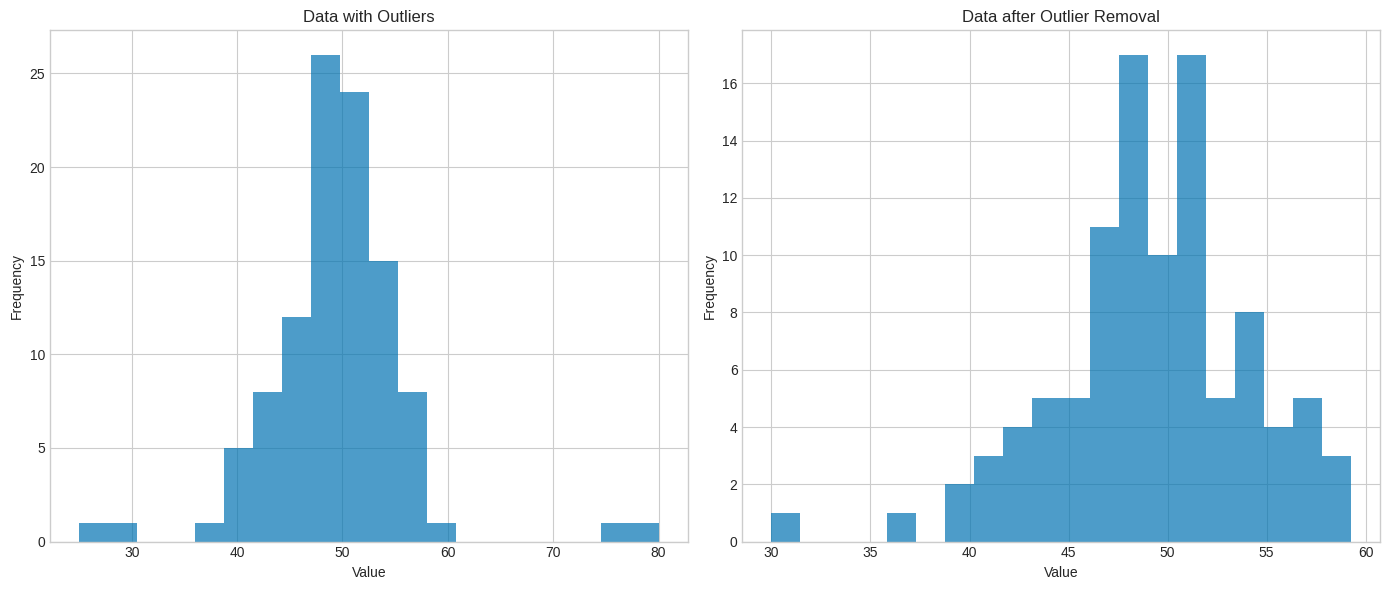

In [50]:
# Create a dataset with outliers
np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=5, size=100)
outliers = np.array([25, 30, 75, 80])
data_with_outliers = np.concatenate([normal_data, outliers])

# Detect outliers using Z-score
outliers_mask = detect_outliers_zscore(data_with_outliers)

# Remove outliers
data_without_outliers = data_with_outliers[~outliers_mask]

# Compare statistics
print("With outliers:")
print(f"Mean: {np.mean(data_with_outliers):.2f}")
print(f"Std: {np.std(data_with_outliers):.2f}")
print(f"Min: {np.min(data_with_outliers):.2f}")
print(f"Max: {np.max(data_with_outliers):.2f}")
print("\nWithout outliers:")
print(f"Mean: {np.mean(data_without_outliers):.2f}")
print(f"Std: {np.std(data_without_outliers):.2f}")
print(f"Min: {np.min(data_without_outliers):.2f}")
print(f"Max: {np.max(data_without_outliers):.2f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].hist(data_with_outliers, bins=20, alpha=0.7)
axes[0].set_title('Data with Outliers')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(data_without_outliers, bins=20, alpha=0.7)
axes[1].set_title('Data after Outlier Removal')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<a id="transformation"></a>
## 4.2 Transformation Strategies

Transformations can reduce the impact of outliers without removing them.

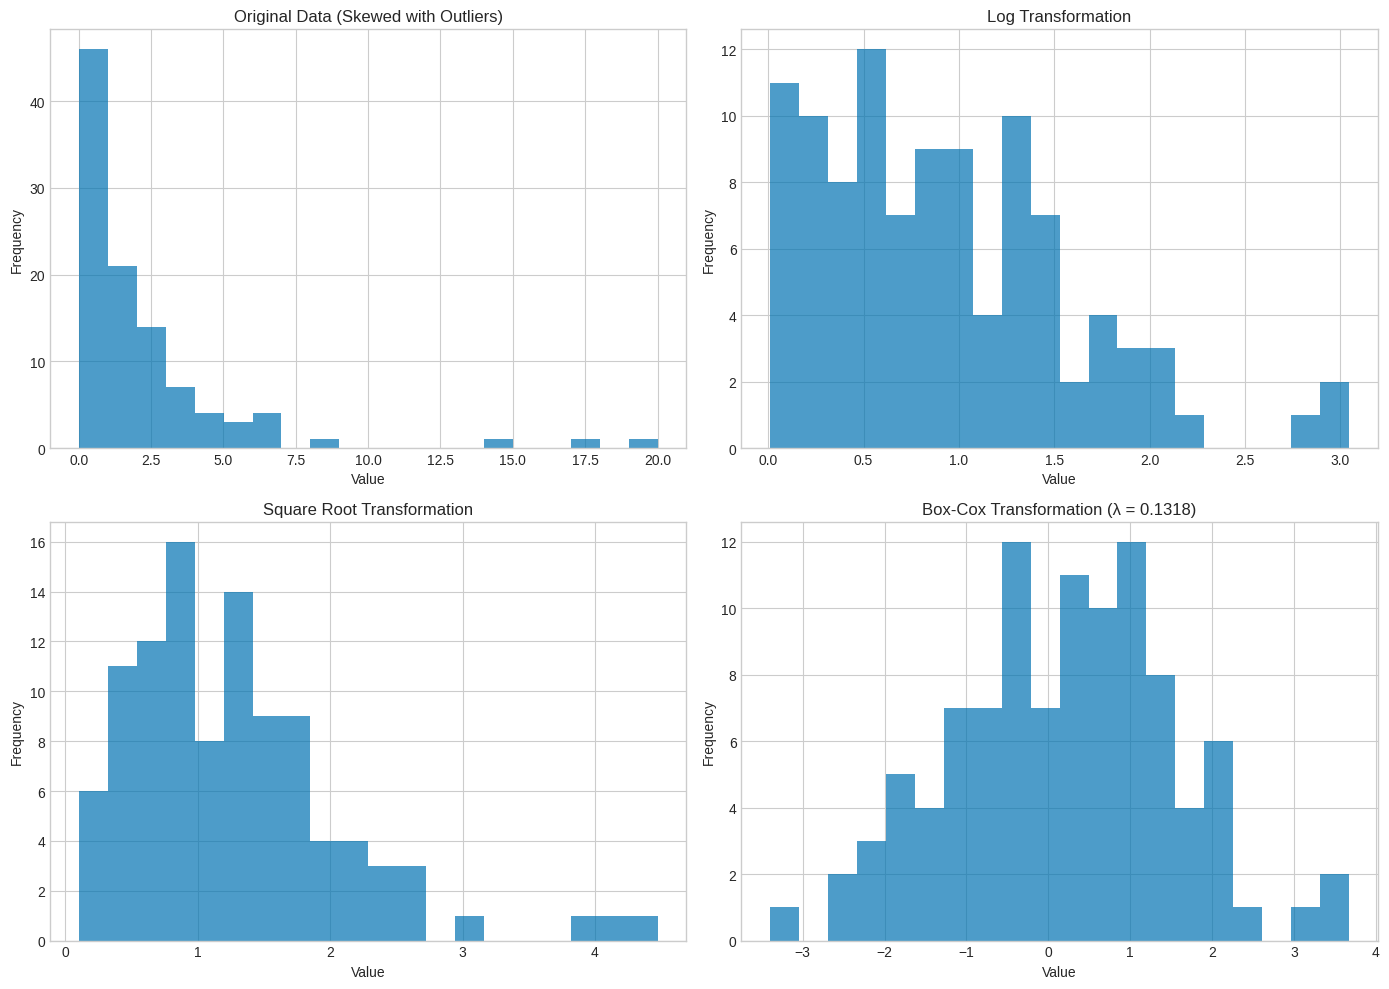

In [51]:
# Create a right-skewed dataset with outliers
np.random.seed(42)
data = np.random.exponential(scale=2, size=100)
outliers = np.array([15, 18, 20])
skewed_data = np.concatenate([data, outliers])

# Apply different transformations
log_transform = np.log1p(skewed_data)  # log(1+x) to handle zeros
sqrt_transform = np.sqrt(skewed_data)
# Box-Cox requires positive data
boxcox_transform, lambda_value = stats.boxcox(skewed_data)

# Visualize
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].hist(skewed_data, bins=20, alpha=0.7)
axes[0, 0].set_title('Original Data (Skewed with Outliers)')
axes[0, 0].set_xlabel('Value')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(log_transform, bins=20, alpha=0.7)
axes[0, 1].set_title('Log Transformation')
axes[0, 1].set_xlabel('Value')
axes[0, 1].set_ylabel('Frequency')

axes[1, 0].hist(sqrt_transform, bins=20, alpha=0.7)
axes[1, 0].set_title('Square Root Transformation')
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(boxcox_transform, bins=20, alpha=0.7)
axes[1, 1].set_title(f'Box-Cox Transformation (λ = {lambda_value:.4f})')
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

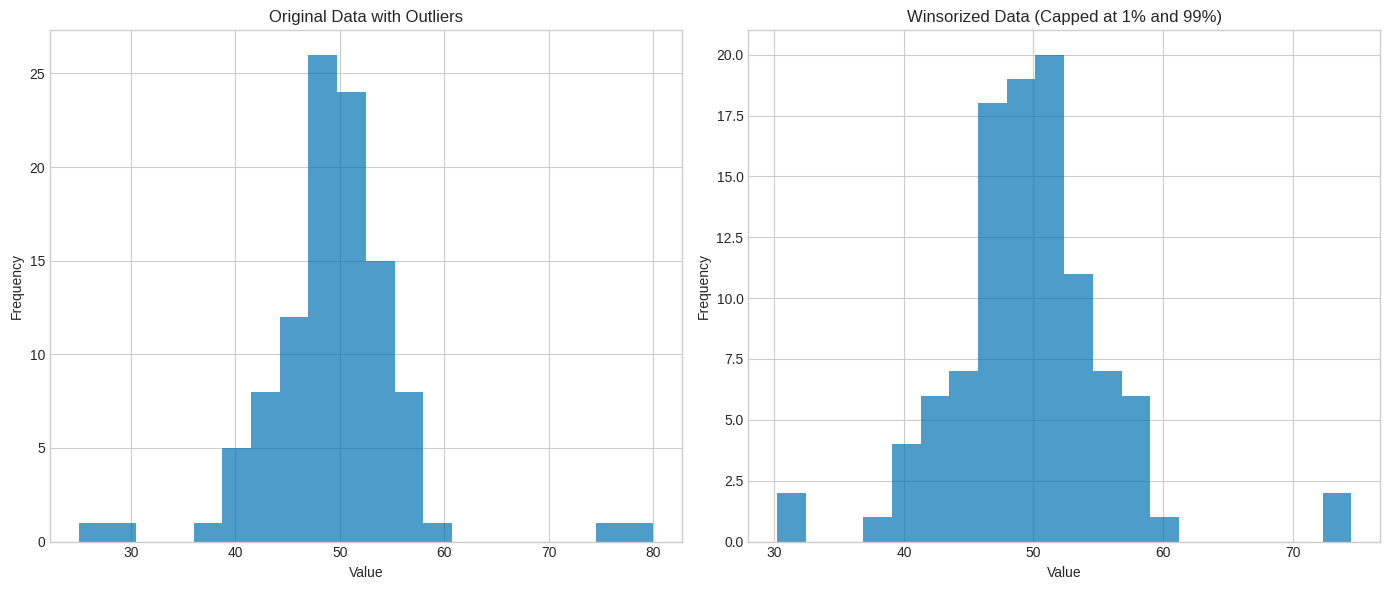

In [52]:
# Winsorizing (capping)
def winsorize(data, limits=(0.05, 0.05)):
    """
    Winsorize data by replacing values outside percentile limits with the values at those limits.

    Parameters:
    data (array-like): Input data
    limits (tuple): Lower and upper percentile limits

    Returns:
    array: Winsorized data
    """
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, (1 - limits[1]) * 100)

    winsorized_data = np.copy(data)
    winsorized_data[winsorized_data < lower_limit] = lower_limit
    winsorized_data[winsorized_data > upper_limit] = upper_limit

    return winsorized_data

# Apply winsorizing
winsorized_data = winsorize(data_with_outliers, limits=(0.01, 0.01))

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].hist(data_with_outliers, bins=20, alpha=0.7)
axes[0].set_title('Original Data with Outliers')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(winsorized_data, bins=20, alpha=0.7)
axes[1].set_title('Winsorized Data (Capped at 1% and 99%)')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<a id="imputation"></a>
## 4.3 Imputation Strategies

Imputation replaces outliers with estimated values.

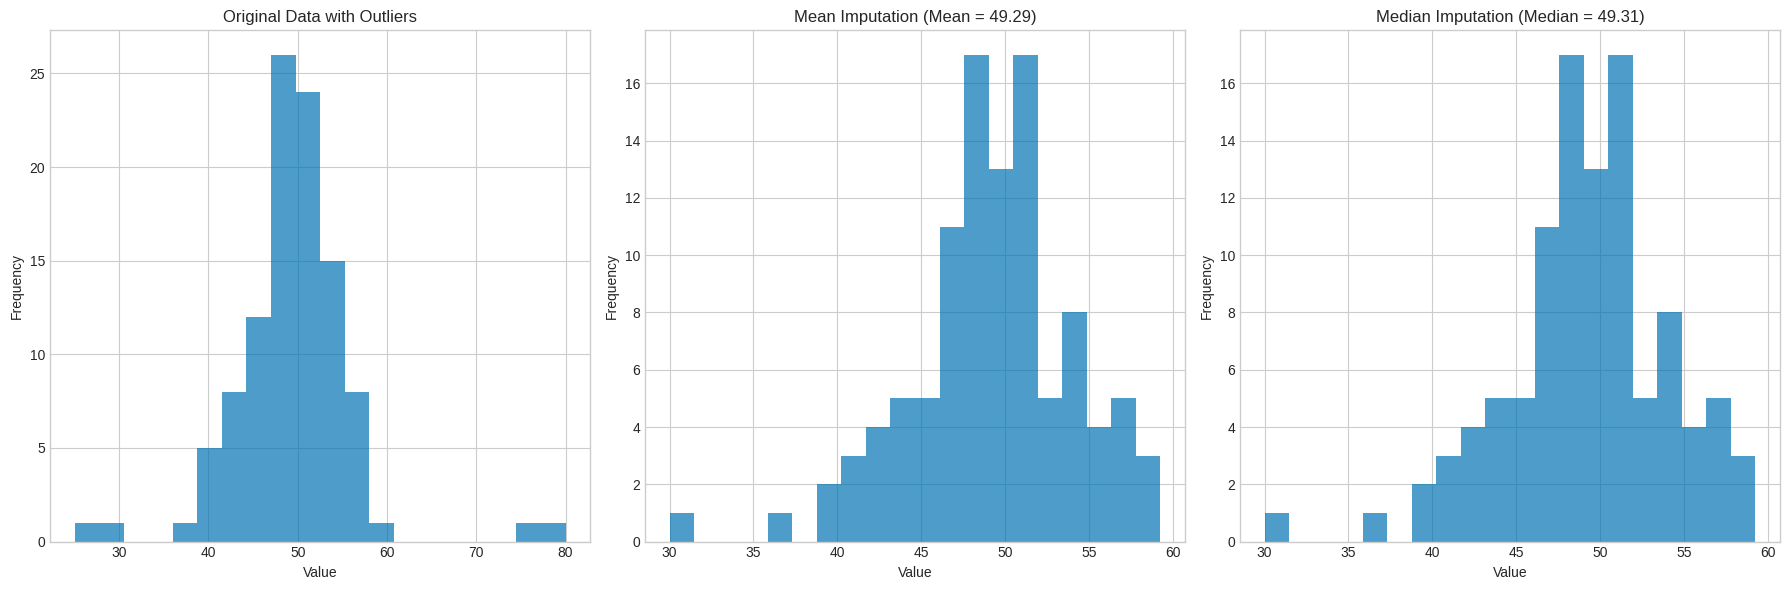

In [53]:
# Create a dataset with outliers
np.random.seed(42)
normal_data = np.random.normal(loc=50, scale=5, size=100)
outliers = np.array([25, 30, 75, 80])
data_with_outliers = np.concatenate([normal_data, outliers])

# Detect outliers using Z-score
outliers_mask = detect_outliers_zscore(data_with_outliers)

# Create copies for different imputation methods
data_mean_imputed = np.copy(data_with_outliers)
data_median_imputed = np.copy(data_with_outliers)

# Mean imputation
mean_value = np.mean(data_with_outliers[~outliers_mask])
data_mean_imputed[outliers_mask] = mean_value

# Median imputation
median_value = np.median(data_with_outliers[~outliers_mask])
data_median_imputed[outliers_mask] = median_value

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].hist(data_with_outliers, bins=20, alpha=0.7)
axes[0].set_title('Original Data with Outliers')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(data_mean_imputed, bins=20, alpha=0.7)
axes[1].set_title(f'Mean Imputation (Mean = {mean_value:.2f})')
axes[1].set_xlabel('Value')
axes[1].set_ylabel('Frequency')

axes[2].hist(data_median_imputed, bins=20, alpha=0.7)
axes[2].set_title(f'Median Imputation (Median = {median_value:.2f})')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

<a id="robust-modeling"></a>
## 4.4 Robust Modeling

Some models are inherently robust to outliers.

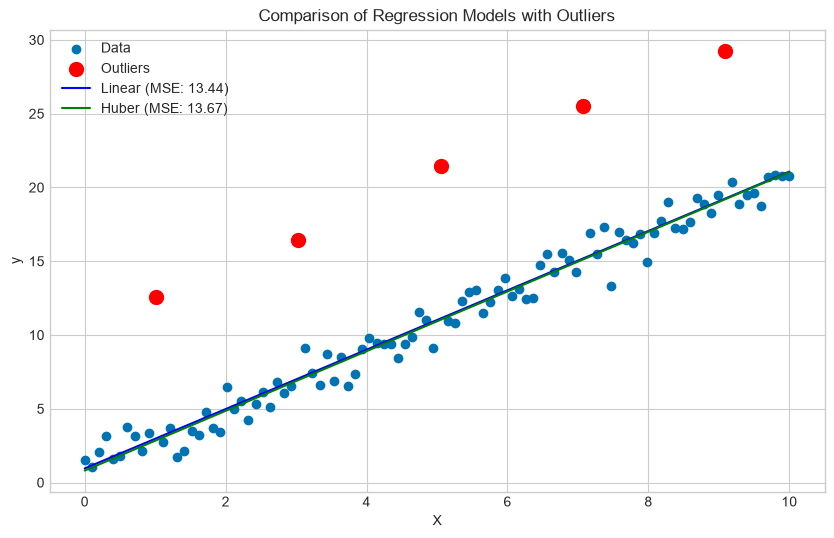

In [37]:
# Create a dataset with outliers for regression
np.random.seed(42)
X = np.linspace(0, 10, 100).reshape(-1, 1)
y = 2 * X.ravel() + 1 + np.random.normal(0, 1, 100)

# Add outliers
outlier_indices = [10, 30, 50, 70, 90]
y[outlier_indices] = y[outlier_indices] + 10

# Split data for demonstration
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Fit models
from sklearn.linear_model import LinearRegression, HuberRegressor
from sklearn.metrics import mean_squared_error

# Standard Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
mse_lr = mean_squared_error(y_test, y_pred_lr)

# Huber Regression (robust to outliers)
huber = HuberRegressor(epsilon=1.35)
huber.fit(X_train, y_train)
y_pred_huber = huber.predict(X_test)
mse_huber = mean_squared_error(y_test, y_pred_huber)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(X, y, label='Data')
plt.scatter(X[outlier_indices], y[outlier_indices], color='red', s=100, label='Outliers')

# Plot regression lines
X_line = np.linspace(0, 10, 100).reshape(-1, 1)
plt.plot(X_line, lr.predict(X_line), color='blue', label=f'Linear (MSE: {mse_lr:.2f})')
plt.plot(X_line, huber.predict(X_line), color='green', label=f'Huber (MSE: {mse_huber:.2f})')

plt.title('Comparison of Regression Models with Outliers')
plt.xlabel('X')
plt.ylabel('y')
#plt.ylim(-5, 50)
plt.legend()
plt.show()

<a id="method-comparison"></a>
# 5. Method Comparison

Let's compare the performance of different outlier detection methods on our complex dataset.

In [71]:
# Create a complex dataset with known outliers
np.random.seed(42)
X_complex, _ = make_blobs(n_samples=300, centers=3, n_features=2, cluster_std=1.0, random_state=42)
outliers_complex = np.array([[8, 8], [-8, -8], [8, -8], [-8, 8], [0, 10], [10, 0], [-10, 0], [0, -10]])
complex_data = np.vstack([X_complex, outliers_complex])

# True outlier labels (1 for outlier, 0 for normal)
true_labels = np.zeros(len(complex_data))
true_labels[-8:] = 1  # Last 8 points are outliers

# Apply different methods
# Z-score (feature by feature)
outliers_zscore = np.zeros(len(complex_data), dtype=bool)
for i in range(complex_data.shape[1]):
    outliers_zscore = outliers_zscore | detect_outliers_zscore(complex_data[:, i])

# IQR (feature by feature)
outliers_iqr = np.zeros(len(complex_data), dtype=bool)
for i in range(complex_data.shape[1]):
    outliers_iqr = outliers_iqr | detect_outliers_iqr(complex_data[:, i])

# LOF
outliers_lof, _ = detect_outliers_lof(complex_data, contamination=0.01)

# Isolation Forest
outliers_if, _ = detect_outliers_iforest(complex_data, contamination=0.01)

# One-Class SVM
outliers_ocsvm, _ = detect_outliers_ocsvm(complex_data, nu=0.01)

# DBSCAN
outliers_dbscan = detect_outliers_dbscan(complex_data, eps=0.5, min_samples=5)

In [72]:
# Evaluate performance
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

methods = {
    'Z-Score': outliers_zscore,
    'IQR': outliers_iqr,
    'LOF': outliers_lof,
    'Isolation Forest': outliers_if,
    'One-Class SVM': outliers_ocsvm,
    'DBSCAN': outliers_dbscan
}

results = []
for name, pred in methods.items():
    precision = precision_score(true_labels, pred)
    recall = recall_score(true_labels, pred)
    f1 = f1_score(true_labels, pred)
    accuracy = accuracy_score(true_labels, pred)
    results.append([name, precision, recall, f1, accuracy])

# Create a DataFrame for results
results_df = pd.DataFrame(results, columns=['Method', 'Precision', 'Recall', 'F1 Score', 'Accuracy'])
results_df.set_index('Method', inplace=True)

# Display results
print(results_df.round(3))

                  Precision  Recall  F1 Score  Accuracy
Method                                                 
Z-Score                 0.0   0.000     0.000     0.974
IQR                     0.0   0.000     0.000     0.974
LOF                     1.0   0.500     0.667     0.987
Isolation Forest        1.0   0.500     0.667     0.987
One-Class SVM           0.6   0.375     0.462     0.977
DBSCAN                  1.0   0.750     0.857     0.994


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


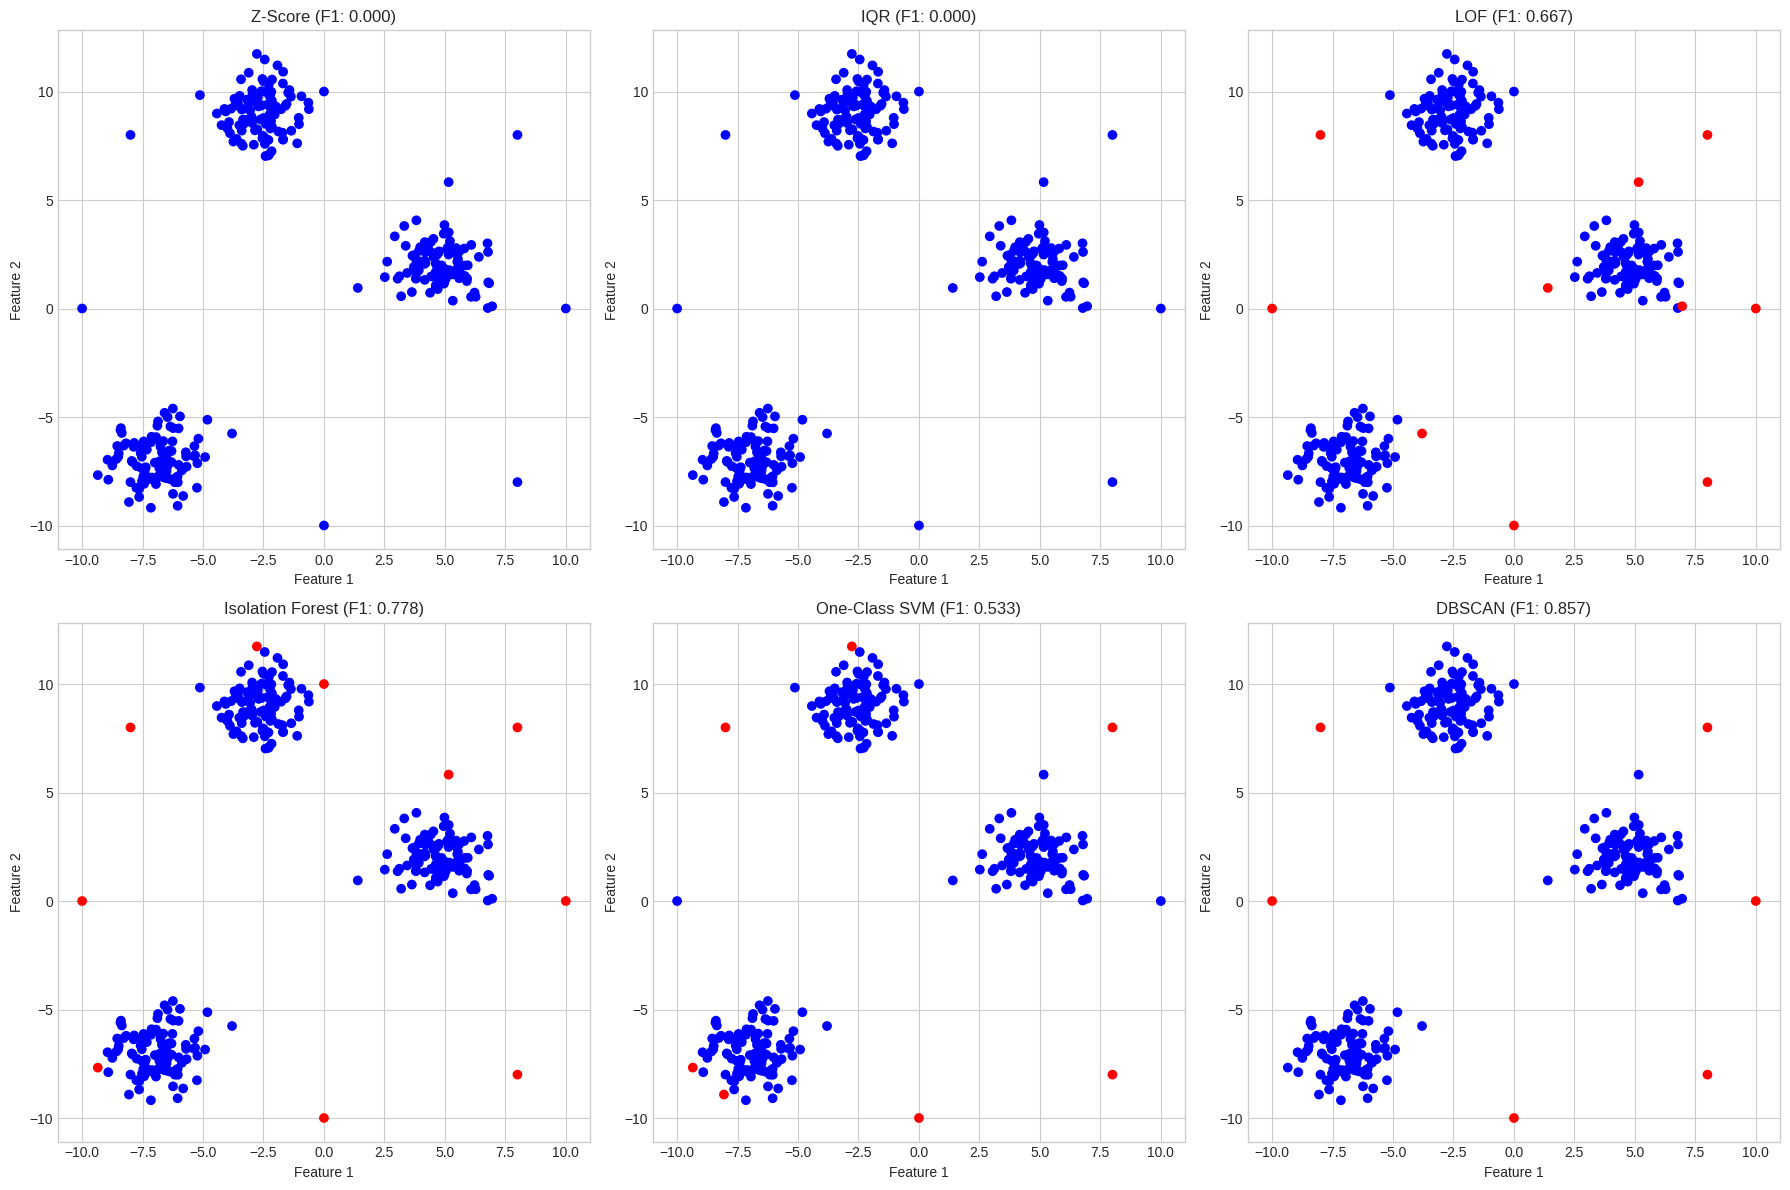

In [57]:
# Visualize results
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, pred) in enumerate(methods.items()):
    axes[i].scatter(complex_data[:, 0], complex_data[:, 1], c=['red' if x else 'blue' for x in pred])
    axes[i].set_title(f'{name} (F1: {f1_score(true_labels, pred):.3f})')
    axes[i].set_xlabel('Feature 1')
    axes[i].set_ylabel('Feature 2')

plt.tight_layout()
plt.show()

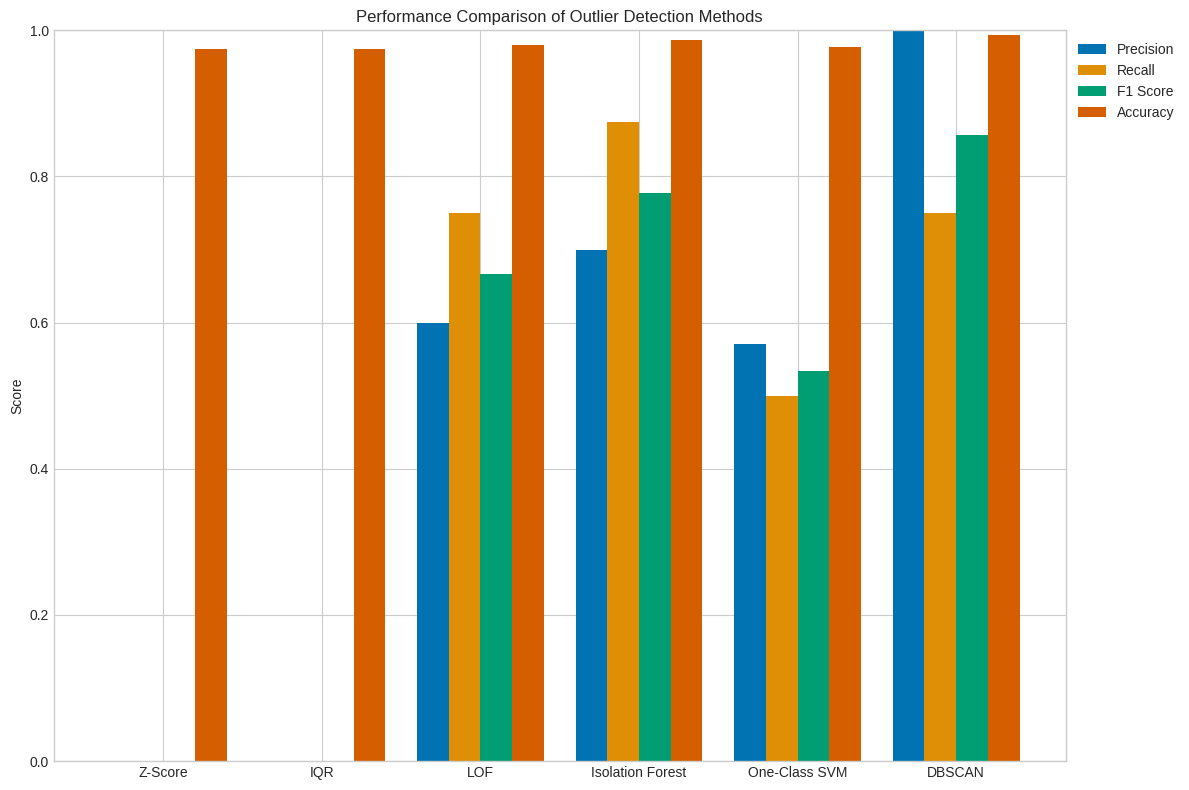

In [58]:
# Plot performance metrics
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
fig, ax = plt.subplots(figsize=(12, 8))

x = np.arange(len(methods))
width = 0.2
multiplier = 0

for metric in metrics:
    offset = width * multiplier
    rects = ax.bar(x + offset, results_df[metric], width, label=metric)
    multiplier += 1

ax.set_ylabel('Score')
ax.set_title('Performance Comparison of Outlier Detection Methods')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(methods.keys())
ax.legend(loc='upper left', bbox_to_anchor=(1, 1))
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

# Conclusion

This notebook has covered various methods for outlier detection and handling, including:

1. Statistical methods: Z-score, IQR, and Modified Z-score
2. Machine learning methods: LOF, Isolation Forest, One-Class SVM, and DBSCAN
3. Handling strategies: Removal, transformation, imputation, and robust modeling

The choice of method depends on the specific characteristics of the data and the goals of the analysis. It's often beneficial to try multiple methods and compare their results.